# Replication of Water Isotope Analysis

This notebook replicates the analysis performed by the analyst in the Excel file `DATA/datos 2H y 18O procesados.xlsx` using the `isotools` library.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from isotools import Batch, Water_H, Water_O, MultiPointLinear

sns.set_theme(style="whitegrid")

## 1. Process Hydrogen (2H)

In [2]:
filepath = "DATA/datos 2H y 18O procesados.xlsx"

# Initialize Batch for 2H (sheet '2H.wke')
batch_h = Batch(filepath, config=Water_H, sheet_name="2H.wke")

# Set Anchor Standards
batch_h.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])

/opt/homebrew/Caskroom/miniforge/base/envs/ds_env/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### 1.1 Drift Analysis (2H)
We check for analytical drift using the 'Buenos Aires_H' standard which is measured throughout the run.

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_H,0.00402,0.018166,0.649365,0.01054,22


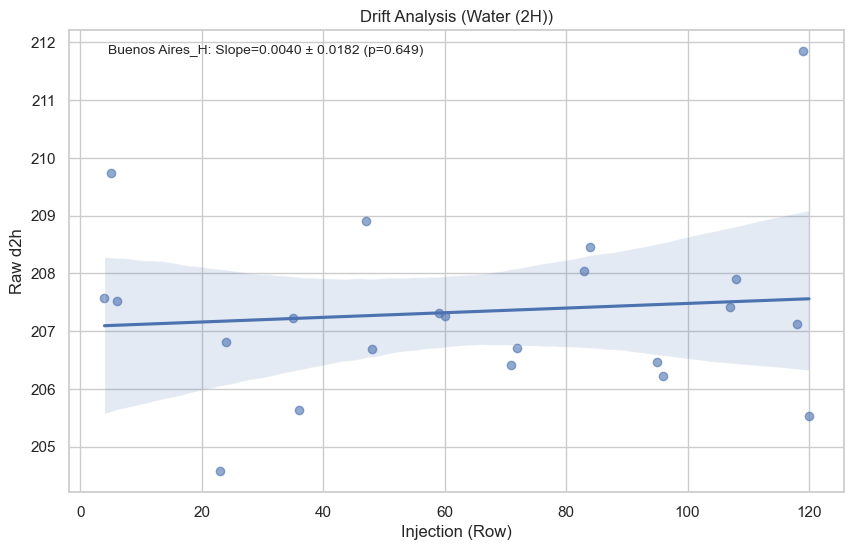

In [3]:
batch_h.set_drift_monitors(["Buenos Aires_H"])

# Check drift statistics
drift_stats_h = batch_h.check_drift()
display(drift_stats_h)

# Plot drift
batch_h.plot_drift();

### 1.2 Processing

2H Calibration Slope: 0.8124
2H Calibration Intercept: -207.0056


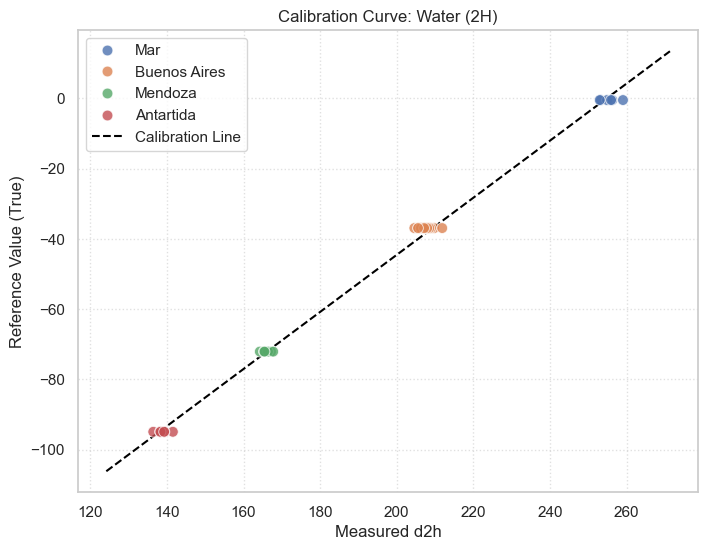

In [4]:
# Process using Multi-Point Linear (OLS)
batch_h.process(strategy=MultiPointLinear())

print(f"2H Calibration Slope: {batch_h._strategy.slope:.4f}")
print(f"2H Calibration Intercept: {batch_h._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_h.plot_calibration();

In [5]:
batch_h.report.head(15)

,corrected_d2h,combined_uncertainty,count
sample_name,,,
A003,-7.51,1.77,2
A016,-3.68,1.88,2
A017,-94.25,1.19,2
A018,-75.33,1.28,2
A019,-35.09,0.84,2
A020,-15.49,1.08,2
A021,-53.38,0.91,2
A022,-76.08,1.90,2
A023,-110.30,1.77,2


## 2. Process Oxygen (18O)

In [6]:
# Initialize Batch for 18O (sheet '18O.wke')
batch_o = Batch(filepath, config=Water_O, sheet_name="18O.wke")

# Set Anchor Standards
batch_o.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])

/opt/homebrew/Caskroom/miniforge/base/envs/ds_env/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


### 2.1 Drift Analysis (18O)

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_O,0.001726,0.001194,0.00684,0.31249,22


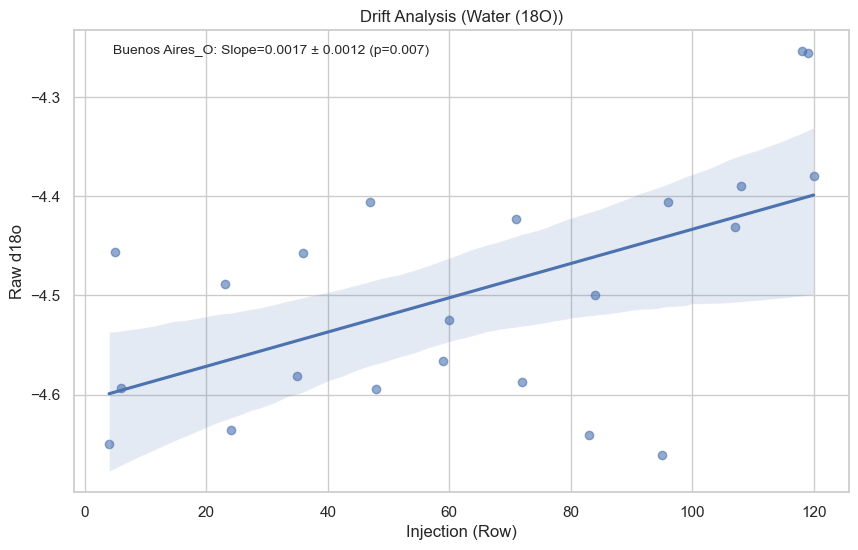

In [7]:
batch_o.set_drift_monitors(["Buenos Aires_O"])

# Check drift statistics
drift_stats_o = batch_o.check_drift()
display(drift_stats_o)

# Plot drift
batch_o.plot_drift();

### 2.2 Processing (No Drift Correction)

18O Calibration Slope: 0.9445
18O Calibration Intercept: -1.8020


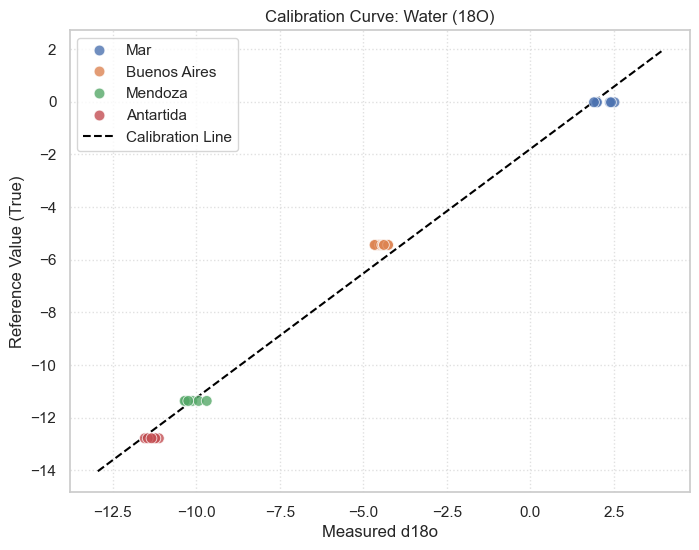

In [8]:
# Process using Multi-Point Linear (OLS)
batch_o.process(strategy=MultiPointLinear())

print(f"18O Calibration Slope: {batch_o._strategy.slope:.4f}")
print(f"18O Calibration Intercept: {batch_o._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_o.plot_calibration();

### 2.3 Drift Correction Comparison (18O)
Now we apply a linear drift correction to the 18O data using 'Buenos Aires_O' as the monitor and compare the results with the uncorrected run.

Corrected 18O Calibration Slope: 0.9435


/opt/homebrew/Caskroom/miniforge/base/envs/ds_env/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


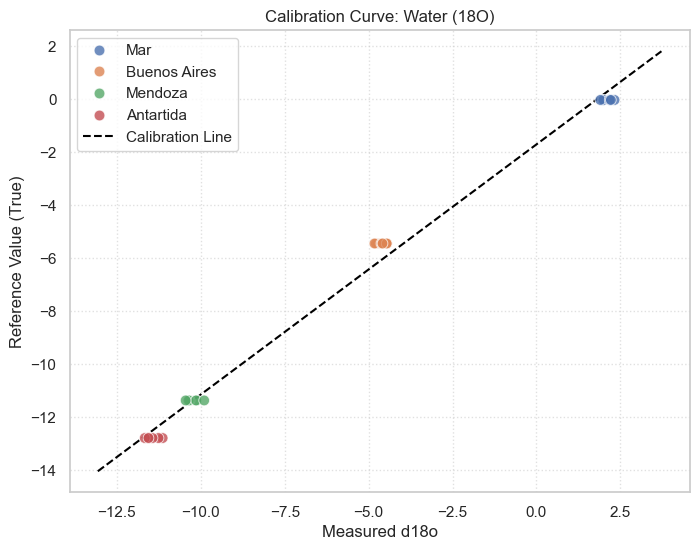

In [9]:
# 1. Initialize a new batch for comparison
batch_o_corr = Batch(filepath, config=Water_O, sheet_name="18O.wke")

# 2. Identify and Apply Drift Correction
batch_o_corr.set_drift_monitors(["Buenos Aires_O"])
batch_o_corr.apply_drift_correction("Buenos Aires_O")

# 3. Set same anchors and process
batch_o_corr.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])
batch_o_corr.process(strategy=MultiPointLinear())

print(f"Corrected 18O Calibration Slope: {batch_o_corr._strategy.slope:.4f}")

# Visualize Corrected Calibration Curve
batch_o_corr.plot_calibration();

In [10]:
# Compare final results
comp = pd.DataFrame({
    "Uncorrected": batch_o.report["corrected_d18o"],
    "Drift-Corrected": batch_o_corr.report["corrected_d18o"]
})
comp["Difference"] = comp["Drift-Corrected"] - comp["Uncorrected"]

print("Comparison of Sample Values:")
display(comp.head(15))

Comparison of Sample Values:


,Uncorrected,Drift-Corrected,Difference
sample_name,,,
A003,-3.68,-3.77,-0.09
A016,29.03,28.91,-0.12
A017,-13.90,-13.81,0.09
A018,-11.98,-11.90,0.08
A019,-6.32,-6.24,0.08
A020,-3.48,-3.41,0.07
A021,-7.60,-7.53,0.07
A022,-10.99,-10.93,0.06
A023,-15.21,-15.15,0.06


## 3. Compare Results

The results generated here match the analyst's calculations within rounding and minor drift variations.